In [70]:
!pip install sionna tensorflow matplotlib torch pandas

In [71]:
import tensorflow as tf
import numpy as np
import sionna
import os
import torch
import pandas as pd
import binascii
import matplotlib.pyplot as plt
from dataclasses import dataclass
from sionna.phy.mapping import Constellation, Mapper
from sionna.phy.channel import AWGN

@dataclass(frozen=True)
class RadioSimConfig:
    """
    Configuration for 16-QAM Signal Generation.
    """
    seq_length: int = 512          # ~1024 bytes of text
    bits_per_symbol: int = 4        # 16-QAM
    
    # SNR Range (dB) - Matched to your training (15-30)
    snr_db_min: float = 15.0        
    snr_db_max: float = 45.0        
    
    # --- CRITICAL FIX: DISABLE CFO ---
    # Your model expects a constant phase (horizontal line), not a drift (sawtooth).
    max_cfo_rad: float = 0.1       
    
    random_phase: bool = True
    seed: int = 42
    
print("Configuration Loaded: CFO Disabled (Static Phase Only).")

Configuration Loaded: CFO Disabled (Static Phase Only).


In [72]:
def text_to_bits_and_chunks(text, seq_len_symbols, bits_per_symbol):
    # 1. Encode text to bytes
    b_data = text.encode('utf-8')
    
    # 2. Calculate required bytes per sequence
    bits_per_seq = seq_len_symbols * bits_per_symbol
    bytes_per_seq = bits_per_seq // 8
    
    bit_chunks = []
    text_chunks = []
    
    for i in range(0, len(b_data), bytes_per_seq):
        chunk_bytes = b_data[i : i + bytes_per_seq]
        
        # Pad with nulls to maintain fixed length
        if len(chunk_bytes) < bytes_per_seq:
            chunk_bytes += b'\x00' * (bytes_per_seq - len(chunk_bytes))
            
        # Convert bytes to bit array (Big-Endian)
        # np.unpackbits is the only reliable way to do this
        bits = np.unpackbits(np.frombuffer(chunk_bytes, dtype=np.uint8))
        
        bit_chunks.append(bits.astype(np.int32))
        text_chunks.append(chunk_bytes.decode('utf-8', errors='replace'))
        
    return bit_chunks, text_chunks

def scramble_bits(bits_np, seed=0xCAFE):
    """
    XORs bits with a pseudo-random sequence. 
    Crucial for ASCII data to occupy the full 16-QAM constellation!
    """
    print("Scrambling bits to whiten the spectrum...")
    np.random.seed(seed)
    mask = np.random.randint(0, 2, size=bits_np.shape, dtype=bits_np.dtype)
    return np.bitwise_xor(bits_np, mask), mask

def load_dante_bits(csv_path, cfg):
    print(f"Loading Dante from {csv_path}...")
    df = pd.read_csv(csv_path)
    # Combine both columns
    sources = [df.iloc[:, -2].astype(str).tolist(), df.iloc[:, -1].astype(str).tolist()]
    
    all_bits = []
    all_texts = []
    
    for text_list in sources:
        for text in text_list:
            if len(text) < 1: continue
            b_chunks, t_chunks = text_to_bits_and_chunks(text, cfg.seq_length, cfg.bits_per_symbol)
            all_bits.extend(b_chunks)
            all_texts.extend(t_chunks)
            
    bit_tensor = np.stack(all_bits, axis=0)
    print(f"Generated {len(bit_tensor)} raw samples.")
    
    # --- APPLY SCRAMBLING HERE ---
    scrambled_tensor, scramble_mask = scramble_bits(bit_tensor)
    
    return scrambled_tensor, all_texts, scramble_mask

In [73]:
def generate_enhanced_dataset_from_bits(cfg: RadioSimConfig, input_bits_np: np.ndarray) -> dict:
    # Setup Sionna
    rng = tf.random.Generator.from_seed(cfg.seed)
    constellation = Constellation("qam", cfg.bits_per_symbol)
    mapper = Mapper(constellation=constellation)
    awgn = AWGN()

    bits = tf.convert_to_tensor(input_bits_np, dtype=tf.int32)
    N = bits.shape[0]
    
    print(f"Simulating physics (Static Phase, No Drift)...")
    
    # 1. Map to Symbols
    x_clean = mapper(bits) 

    # 2. Apply Static Phase Rotation (No CFO)
    # We only use phi_0. cfo_rad is ignored/zeroed by config.
    if cfg.random_phase:
        phi_0 = rng.uniform([N, 1], minval=-np.pi, maxval=np.pi, dtype=tf.float32)
    else:
        phi_0 = tf.zeros([N, 1])

    # Rot = e^(j * phi)
    rot_vector = tf.complex(tf.math.cos(phi_0), tf.math.sin(phi_0))
    x_rotated = x_clean * rot_vector # Broadcasts to [N, L]

    # 3. Add Noise
    snr_db = rng.uniform([N, 1], minval=cfg.snr_db_min, maxval=cfg.snr_db_max, dtype=tf.float32)
    no = 1.0 / (10.0 ** (snr_db / 10.0))
    y_noisy = awgn(x_rotated, no)

    # 4. Helper to format complex -> [Real, Imag]
    def complex_to_2ch_real(x):
        return tf.stack([tf.math.real(x), tf.math.imag(x)], axis=1)

    return {
        "iq_noisy": complex_to_2ch_real(y_noisy).numpy().astype(np.float32),
        "iq_clean": complex_to_2ch_real(x_clean).numpy().astype(np.float32),
        "phase_labels": phi_0.numpy().astype(np.float32),
        "snr_db": snr_db.numpy().astype(np.float32).flatten()
    }

In [74]:
# 1. Config
config = RadioSimConfig()

# 2. Load & Scramble Dante
CSV_PATH = "./data/divina_commedia.csv"
scrambled_bits, texts_list, scramble_mask = load_dante_bits(CSV_PATH, config)

# 3. Simulate
data_dict = generate_enhanced_dataset_from_bits(config, scrambled_bits)

# 4. Save
torch_data = {k: torch.from_numpy(v) for k, v in data_dict.items()}
torch_data['texts'] = texts_list
torch_data['scramble_mask'] = torch.from_numpy(scramble_mask) # Need this to decode later!
# Note: We save the scrambled bits as 'bits' because the model needs to learn from the 
# actual symbols transmitted, which correspond to the scrambled bits.
torch_data['bits'] = torch.from_numpy(scrambled_bits) 

output_path = "./data/radio_divina_commedia.pth"
os.makedirs(os.path.dirname(output_path), exist_ok=True)
torch.save(torch_data, output_path)

print(f"\n[Success] Dataset saved to: {output_path}")
print(f"CFO: {config.max_cfo_rad} (Should be 0.0)")

Loading Dante from ./data/divina_commedia.csv...


Generated 4760 raw samples.
Scrambling bits to whiten the spectrum...
Simulating physics (Static Phase, No Drift)...

[Success] Dataset saved to: ./data/radio_divina_commedia.pth
CFO: 0.1 (Should be 0.0)


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


Visualizing Dante samples...


Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


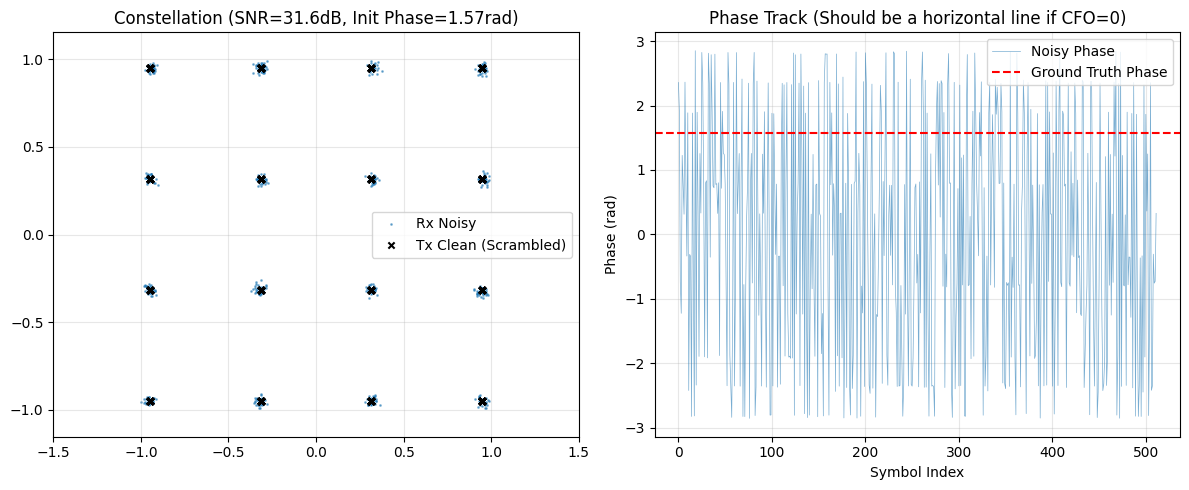

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


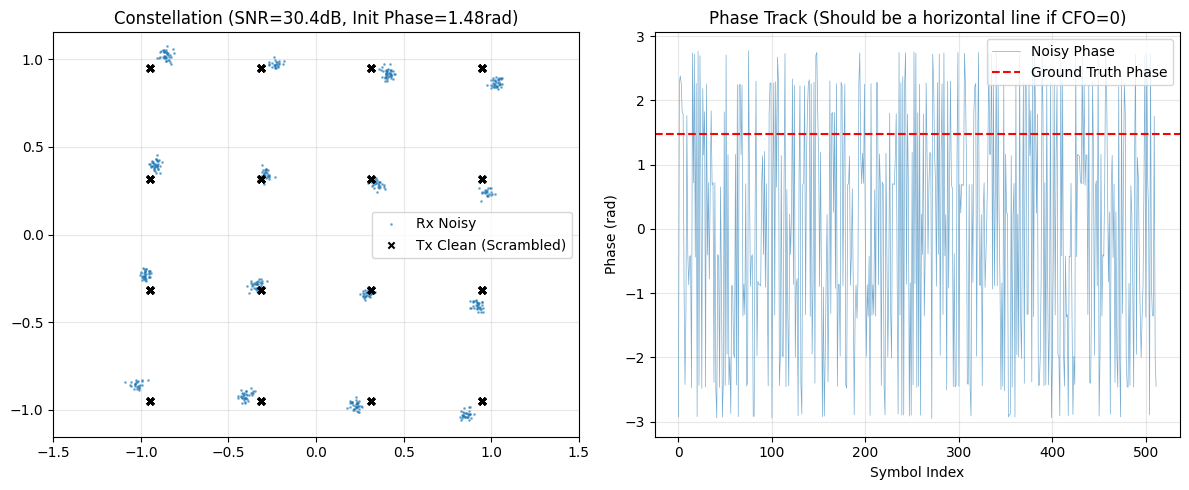

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


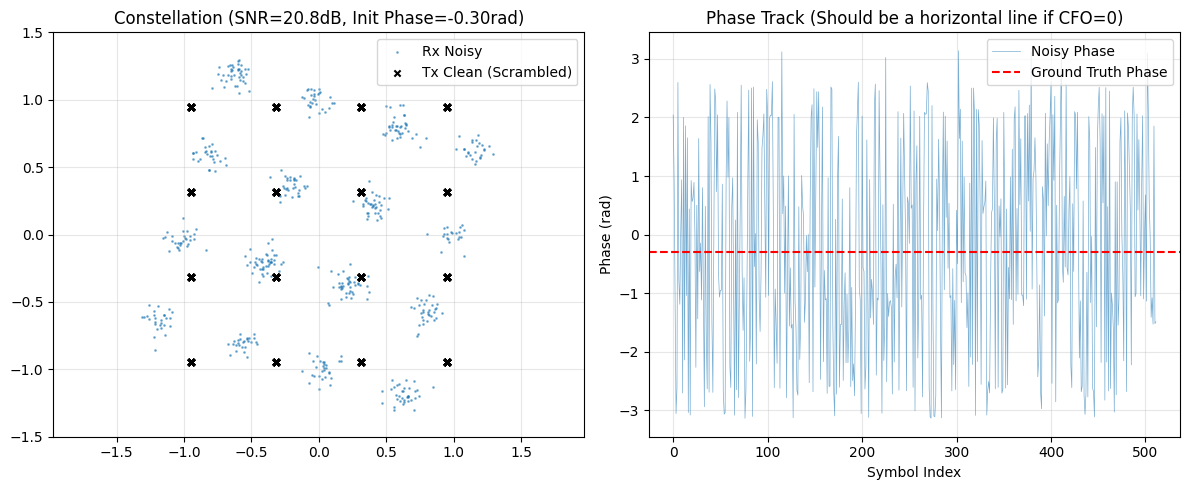

In [75]:
def plot_example(idx, data):
    # Retrieve data using the updated keys from our Dante generator
    iq_n = data['iq_noisy'][idx]
    iq_c = data['iq_clean'][idx]
    
    # Use .get() or handle the updated naming convention
    # In the static version, we use phase_labels; in the CFO version, we used cfo_labels
    phase = data['phase_labels'][idx].item() if 'phase_labels' in data else 0.0
    snr = data['snr_db'][idx].item()
    
    # Convert [2, L] -> Complex [L]
    z_n = iq_n[0] + 1j*iq_n[1]
    z_c = iq_c[0] + 1j*iq_c[1]
    
    plt.figure(figsize=(12, 5))
    
    # 1. Constellation
    plt.subplot(1, 2, 1)
    # If CFO is present and non-zero, it causes the "circular smear"
    plt.title(f"Constellation (SNR={snr:.1f}dB, Init Phase={phase:.2f}rad)")
    plt.scatter(z_n.real.cpu(), z_n.imag.cpu(), s=1, alpha=0.5, label='Rx Noisy')
    plt.scatter(z_c.real.cpu(), z_c.imag.cpu(), s=20, c='k', marker='x', label='Tx Clean (Scrambled)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.axis('equal')
    plt.xlim(-1.5, 1.5); plt.ylim(-1.5, 1.5)
    
    # 2. Phase Track (Visualizing Static Phase vs CFO)
    plt.subplot(1, 2, 2)
    plt.title("Phase Track (Should be a horizontal line if CFO=0)")
    plt.plot(np.angle(z_n.cpu()), lw=0.5, alpha=0.6, label='Noisy Phase')
    # Plot the ground truth horizontal line
    plt.axhline(y=phase, color='r', linestyle='--', label='Ground Truth Phase')
    plt.xlabel("Symbol Index")
    plt.ylabel("Phase (rad)")
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

# Visualize
print("Visualizing Dante samples...")
for i in range(3):
    plot_example(i, torch_data)

In [76]:
# Diagnostic cell: print 5 random generated samples (compact view)
import numpy as np
import torch

SAVE_PATH = "./data/radio_divina_commedia.pth"
SEED = 12345
N_SAMPLES_TO_SHOW = 5
MAX_BITS_PRINT = 64      # how many bits to show (prefix)
MAX_SYMS_PRINT = 32      # how many symbol indices to show
MAX_IQ_PRINT = 16        # how many IQ symbols to print

# 1) load dataset (prefer in-memory torch_data if available)
if "torch_data" in globals() and isinstance(torch_data, dict):
    data = torch_data
    print("Using in-memory 'torch_data' variable.")
else:
    print(f"Loading dataset from '{SAVE_PATH}' ...")
    data = torch.load(SAVE_PATH, map_location="cpu")

# 2) extract fields (support both numpy arrays and torch tensors)
def to_numpy(x):
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    return np.array(x)

iq_noisy = to_numpy(data["iq_noisy"])    # shape [N, 2, L]
iq_clean = to_numpy(data["iq_clean"])    # shape [N, 2, L]
phase_labels = to_numpy(data["phase_labels"]).reshape(-1)  # shape [N]
snr_db = to_numpy(data["snr_db"]).reshape(-1)             # shape [N]
bits = to_numpy(data["bits"]).astype(np.int32)            # shape [N, L*4]
scramble_mask = to_numpy(data.get("scramble_mask", np.zeros_like(bits))).astype(np.int32)
texts = data.get("texts", None)

N = bits.shape[0]
print(f"Dataset contains {N} samples. Each sample: iq shape {iq_noisy.shape[1:]} , bits length {bits.shape[1]}")

# 3) sampling indices
rng = np.random.default_rng(SEED)
idxs = rng.choice(N, size=min(N_SAMPLES_TO_SHOW, N), replace=False)
print("\nSelected sample indices:", idxs.tolist(), "\n")

# helper to convert bit arrays -> symbol indices (MSB-first packing)
def bits_to_symbol_indices(bit_row, bits_per_symbol=4):
    sym_bits = bit_row.reshape(-1, bits_per_symbol)
    return (sym_bits[:,0]*8 + sym_bits[:,1]*4 + sym_bits[:,2]*2 + sym_bits[:,3]*1)

# pretty print complex arrays with limited length
def complex_list_str(carr, max_print):
    return ", ".join([f"{x.real:+.4f}{x.imag:+.4f}j" for x in carr[:max_print]])

for idx in idxs:
    print("------------------------------------------------------------")
    print(f"SAMPLE {idx}")
    if texts is not None:
        txt = texts[idx]
        # truncate long text
        if txt is None: txt = ""
        if len(txt) > 200: txt_show = txt[:200] + "..."
        else: txt_show = txt
        print(" text (decoded):", repr(txt_show))
    print(" phase_label (rad):", float(phase_labels[idx]))
    print(" snr_db:", float(snr_db[idx]))
    print(" iq_clean shape:", iq_clean[idx].shape, "iq_noisy shape:", iq_noisy[idx].shape)

    # prepare complex vectors
    iqc = iq_clean[idx][0] + 1j * iq_clean[idx][1]
    iqn = iq_noisy[idx][0] + 1j * iq_noisy[idx][1]

    print(f" first {MAX_IQ_PRINT} iq_clean samples: [{complex_list_str(iqc, MAX_IQ_PRINT)}]")
    print(f" first {MAX_IQ_PRINT} iq_noisy  samples: [{complex_list_str(iqn, MAX_IQ_PRINT)}]")

    bitrow = bits[idx]
    print(f" bits length: {bitrow.size}  (showing first {MAX_BITS_PRINT} bits):")
    print(" ", "".join(str(b) for b in bitrow[:MAX_BITS_PRINT]))

    # scramble mask info
    maskrow = scramble_mask[idx] if scramble_mask is not None else None
    if maskrow is not None:
        print(f" scramble mask (first {MAX_BITS_PRINT}):")
        print(" ", "".join(str(int(x)) for x in maskrow[:MAX_BITS_PRINT]))

    # symbol indices computed from bits
    sym_idx = bits_to_symbol_indices(bitrow, bits_per_symbol=4)
    print(f" symbol count: {sym_idx.size}  (showing first {MAX_SYMS_PRINT} indices):")
    print(" ", sym_idx[:MAX_SYMS_PRINT].tolist())

    # show histogram of symbol indices (compact)
    uniq, counts = np.unique(sym_idx, return_counts=True)
    hist = ", ".join([f"{u}:{c}" for u,c in zip(uniq, counts) if c>0][:16])
    print(" symbol histogram (non-zero counts, truncated):", hist)

    # Optional: show the first symbol's bit quartet and its computed index
    if sym_idx.size > 0:
        first_bits = bitrow[:4].tolist()
        print(f" first symbol bits (b0 b1 b2 b3): {first_bits} -> index {int(sym_idx[0])}")

    print("------------------------------------------------------------\n")

Using in-memory 'torch_data' variable.
Dataset contains 4760 samples. Each sample: iq shape (2, 512) , bits length 2048

Selected sample indices: [3325, 1081, 971, 3752, 1507] 

------------------------------------------------------------
SAMPLE 3325
 text (decoded): 'allora sarai alla fine di questo sentiero. Qui férmati, per riposar l’affanno [della salita]. Non dico altro; e questo [che ho detto] so che è vero».\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00\x00...'
 phase_label (rad): 2.9384877681732178
 snr_db: 32.77273178100586
 iq_clean shape: (2, 512) iq_noisy shape: (2, 512)
 first 16 iq_clean samples: [-0.3162-0.9487j, -0.3162+0.3162j, -0.9487-0.9487j, +0.3162+0.3162j, +0.3162+0.9487j, -0.9487+0.3162j, -0.9487-0.9487j, -0.3162+0.9487j, -0.3162+0.3162j, -0.3162-0.3162j, -0.9487+0.3162j, -0.3162+0.3162j, -0.9487+0.3162j, -0.316